# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 17: Modelos de Provisiones bajo IFRS 9.**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s17")
model_path = os.path.join(absolute_path, "models")
figure_path = os.path.join(absolute_path, "figuras", "s17")

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

**Objetivo de la sesión**

Bajo el marco de **IFRS 9**, las entidades financieras deben estimar la **Probabilidad de Incumplimiento (PD)** incorporando información **prospectiva** (*forward-looking*). Esto implica vincular la PD observada históricamente con variables macroeconómicas y proyectar su comportamiento futuro bajo distintos escenarios.

En esta sesión construiremos, paso a paso, el flujo completo:

```
PD Histórica → Logit(PD) → Macromodelo → PD Proyectada (PIT) → PD Final (TTC ajustada)
```

**Flujo de trabajo**
| Paso | Descripción |
|------|-------------|
| 0 | Carga y exploración de datos |
| 1 | Transformación de variables (logit PD + transformaciones macro) |
| 2 | Construcción de rezagos y adelantos |
| 3 | Test de estacionariedad y suavización |
| 4 | Selección de variables y estimación de 3 modelos candidatos |
| 5 | Diagnóstico y selección del modelo final |
| 6 | Proyección de la PD (2019–2022) |
| 7 | Cálculo de PD PIT, PD TTC y PD Final IFRS 9 |

## **1. Carga de Datos**

In [2]:
# ── Carga del archivo ──────────────────────────────────────────────────────
df_raw = pd.read_excel(os.path.join(data_path, 'pd_vehicular.xlsx'))
df_raw.head()

,periodo,pd,GDPR,Unemployment,GFCF,Consumption,InterestRatesReal,EMBI,FiscalBalance,FX,Sov1Y,Sov2Y,Sov3Y,Sov10Y
0,2009-1Q,0.093006,82894.9333,0.091441,17323.6043,51955.7031,0.004073,424.0,0.000442,3.176436,0.005963,0.001885,0.002894,0.011434
1,2009-2Q,0.098985,88427.1789,0.085754,17369.9666,54288.8216,-0.009647,271.0,0.000243,2.992076,-0.003205,-0.001067,0.001383,0.018018
2,2009-3Q,0.098330,88282.9843,0.081000,20436.8753,55382.1466,-0.006651,207.0,-0.000325,2.910577,0.008746,0.011079,0.013697,0.035217
3,2009-4Q,0.096908,92978.9204,0.075777,24557.6477,54258.4193,0.008355,167.0,-0.000828,2.878647,0.023067,0.025510,0.028128,0.052960
4,2010-1Q,0.094972,87418.2071,0.091234,20058.6545,55488.6910,0.005746,146.0,0.000341,2.840100,0.020815,0.023258,0.026047,0.053078


In [3]:
# Separar serie histórica (PD observada) de proyecciones macro
# La PD existe hasta 2018-4Q (primeras 40 filas)
# Las variables macro tienen proyecciones hasta 2022 aprox.
df_raw = df_raw.dropna(subset=['GDPR'])          # Eliminar filas sin ninguna macro
df_raw = df_raw.reset_index(drop=True)

# Construir índice temporal para las filas sin 'periodo' (proyecciones)
# Reconstruir el campo periodo completo
# Las primeras 40 filas tienen periodo; las siguientes lo tienen sin llenar
periodos_obs  = df_raw.loc[df_raw['periodo'].notna(), 'periodo'].tolist()
n_obs         = len(periodos_obs)
n_proj        = df_raw['periodo'].isna().sum()

# Generar secuencia de trimestres para la parte de proyección
def gen_quarters(start_year, start_q, n):
    quarters = []
    y, q = start_year, start_q
    for _ in range(n):
        quarters.append(f"{y}-{q}Q")
        q += 1
        if q > 4:
            q = 1
            y += 1
    return quarters

# El último periodo observado es 2022-4Q → proyección empieza en 2023-1Q
ultimo_periodo_macro = '2022-4Q'
periodos_proj = gen_quarters(2023, 1, n_proj)

# Asignar periodos completos
todos_periodos = periodos_obs + periodos_proj
df_raw['periodo'] = todos_periodos[:len(df_raw)]

print(f"Total de periodos con datos macro: {len(df_raw)}")
print(f"  → Observaciones con PD histórica : {df_raw['pd'].notna().sum()} ({df_raw.loc[df_raw['pd'].notna(),'periodo'].iloc[0]} – {df_raw.loc[df_raw['pd'].notna(),'periodo'].iloc[-1]})")
print(f"  → Periodos de proyección macro   : {df_raw['pd'].isna().sum()} ({df_raw.loc[df_raw['pd'].isna(),'periodo'].iloc[0]} – {df_raw['periodo'].iloc[-1]})")
df_raw.head()

Total de periodos con datos macro: 64
  → Observaciones con PD histórica : 40 (2009-1Q – 2018-4Q)
  → Periodos de proyección macro   : 24 (2019-1Q – 2024-4Q)


,periodo,pd,GDPR,Unemployment,GFCF,Consumption,InterestRatesReal,EMBI,FiscalBalance,FX,Sov1Y,Sov2Y,Sov3Y,Sov10Y
0,2009-1Q,0.093006,82894.9333,0.091441,17323.6043,51955.7031,0.004073,424.0,0.000442,3.176436,0.005963,0.001885,0.002894,0.011434
1,2009-2Q,0.098985,88427.1789,0.085754,17369.9666,54288.8216,-0.009647,271.0,0.000243,2.992076,-0.003205,-0.001067,0.001383,0.018018
2,2009-3Q,0.098330,88282.9843,0.081000,20436.8753,55382.1466,-0.006651,207.0,-0.000325,2.910577,0.008746,0.011079,0.013697,0.035217
3,2009-4Q,0.096908,92978.9204,0.075777,24557.6477,54258.4193,0.008355,167.0,-0.000828,2.878647,0.023067,0.025510,0.028128,0.052960
4,2010-1Q,0.094972,87418.2071,0.091234,20058.6545,55488.6910,0.005746,146.0,0.000341,2.840100,0.020815,0.023258,0.026047,0.053078


## **2. Transformación de variables**

### 2.1 Transformación de la PD: Logit

La PD es una probabilidad acotada en (0, 1). Para modelarla con regresión lineal necesitamos transformarla al espacio real $(-\infty, +\infty)$. La transformación **logit** es la más usada en credit scoring:

$$\text{PD\_logit} = \ln\left(\frac{PD}{1 - PD}\right)$$

Esta es exactamente la función inversa de la sigmoide, y garantiza que el modelo proyecte PDs siempre entre 0 y 1 al aplicar la transformación inversa.

### 2.2 Transformaciones de las variables macro

Para cada variable macroeconómica se construyen **tres versiones** que capturan distintos aspectos de su comportamiento:

| Sufijo | Fórmula | Interpreta |
|--------|---------|------------|
| `_difa` | $X_t - X_{t-1}$ | Cambio absoluto (velocidad) |
| `_log`  | $\ln(X_t)$ | Nivel en escala logarítmica |
| `_logdifa` | $\ln(X_t) - \ln(X_{t-1}) = \ln(X_t/X_{t-1})$ | Tasa de crecimiento (%) |

> **Nota:** Variables que pueden ser negativas (FiscalBalance, InterestRatesReal) **no** admiten log directamente → se usan solo `_difa` y `_logdifa` en sentido de diferencias, o se omite el log.


In [4]:
df = df_raw.copy()

# ── 1.1 Logit de la PD ────────────────────────────────────────────────────
# Clip para evitar 0 o 1 exactos (evita -inf / +inf)
eps = 1e-6
df['PD_logit'] = np.log(df['pd'].clip(eps, 1 - eps) / (1 - df['pd'].clip(eps, 1 - eps)))

# ── 1.2 Transformaciones de variables macro ───────────────────────────────
MACRO_VARS = ['GDPR', 'Unemployment', 'GFCF', 'Consumption',
              'InterestRatesReal', 'EMBI', 'FiscalBalance',
              'FX', 'Sov1Y', 'Sov2Y', 'Sov3Y', 'Sov10Y']

# Variables que pueden tener valores <= 0 → no aplicar log
NO_LOG_VARS = ['InterestRatesReal', 'FiscalBalance', 'Sov1Y', 'Sov2Y', 'Sov3Y', 'Sov10Y']

transformed_cols = []

for var in MACRO_VARS:
    # Diferencia absoluta
    col_difa = f'{var}_difa'
    df[col_difa] = df[var].diff(1)
    transformed_cols.append(col_difa)

    if var not in NO_LOG_VARS:
        # Log nivel
        col_log = f'{var}_log'
        df[col_log] = np.log(df[var].clip(lower=eps))
        transformed_cols.append(col_log)

        # Log diferencia (tasa de crecimiento)
        col_logdifa = f'{var}_logdifa'
        df[col_logdifa] = df[col_log].diff(1)
        transformed_cols.append(col_logdifa)
    else:
        # Para vars con posibles negativos: diff de diff (aceleración)
        col_logdifa = f'{var}_logdifa'
        df[col_logdifa] = df[col_difa].diff(1)
        transformed_cols.append(col_logdifa)

print(f"Variables transformadas: {len(transformed_cols)} columnas generadas")
print("\nEjemplo (GDPR):")
df[['periodo', 'GDPR', 'GDPR_difa', 'GDPR_log', 'GDPR_logdifa']].head(8)

Variables transformadas: 30 columnas generadas

Ejemplo (GDPR):


,periodo,GDPR,GDPR_difa,GDPR_log,GDPR_logdifa
0,2009-1Q,82894.9333,NaN,11.325329,NaN
1,2009-2Q,88427.1789,5532.2456,11.389935,0.064605
2,2009-3Q,88282.9843,-144.1946,11.388303,-0.001632
3,2009-4Q,92978.9204,4695.9361,11.440128,0.051825
4,2010-1Q,87418.2071,-5560.7133,11.378459,-0.061669
5,2010-2Q,96887.2615,9469.0544,11.481303,0.102844
6,2010-3Q,96918.8232,31.5617,11.481629,0.000326
7,2010-4Q,101155.7078,4236.8846,11.524416,0.042787


array([[<Axes: title={'center': 'pd'}>, <Axes: title={'center': 'GDPR'}>,
        <Axes: title={'center': 'Unemployment'}>,
        <Axes: title={'center': 'GFCF'}>],
       [<Axes: title={'center': 'Consumption'}>,
        <Axes: title={'center': 'InterestRatesReal'}>,
        <Axes: title={'center': 'EMBI'}>,
        <Axes: title={'center': 'FiscalBalance'}>],
       [<Axes: title={'center': 'FX'}>,
        <Axes: title={'center': 'Sov1Y'}>,
        <Axes: title={'center': 'Sov2Y'}>,
        <Axes: title={'center': 'Sov3Y'}>],
       [<Axes: title={'center': 'Sov10Y'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

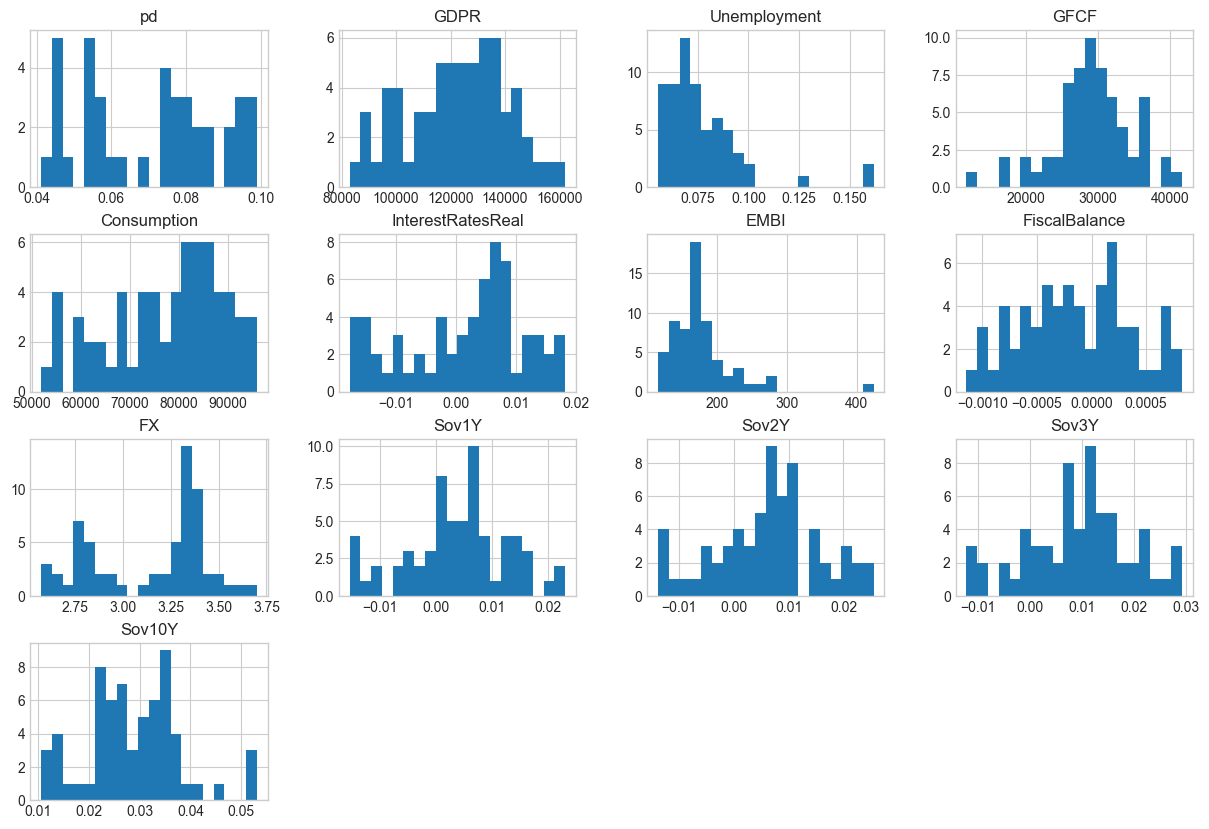

In [5]:
df_raw.hist(bins=20, figsize=(15, 10), color=COLORS[0])

## **4. Test de estacionariedad y suavización**

La regresión lineal sobre series de tiempo supone que las series son **estacionarias** (media y varianza constantes en el tiempo). Si no lo son, los coeficientes pueden ser espurios.

### Test de Dickey-Fuller Aumentado (ADF)
- **H₀**: La serie tiene raíz unitaria (NO estacionaria)
- **H₁**: La serie es estacionaria
- Si **p-value < 0.05** → rechazamos H₀ → la serie **sí es estacionaria** ✅
- Si **p-value ≥ 0.05** → no rechazamos H₀ → la serie **NO es estacionaria** ❌ → aplicar suavización

### Suavización exponencial simple (SES)
Cuando una serie no es estacionaria, aplicamos suavización exponencial con parámetro $\alpha$:
$$\hat{X}_t = \alpha X_t + (1-\alpha)\hat{X}_{t-1}$$
Esto reduce el ruido sin perder la tendencia de largo plazo.

In [6]:
# ── Función ADF ──────────────────────────────────────────────────────────
def test_adf(series, nombre, alpha=0.05):
    """Retorna dict con resultado del test ADF."""
    serie_limpia = series.dropna()
    if len(serie_limpia) < 10:
        return {'variable': nombre, 'pvalue': np.nan, 'estacionaria': 'insuficiente'}
    result = adfuller(serie_limpia, autolag='AIC')
    es_estac = result[1] < alpha
    return {
        'variable'    : nombre,
        'adf_stat'    : round(result[0], 4),
        'pvalue'      : round(result[1], 4),
        'estacionaria': '✅ Sí' if es_estac else '❌ No'
    }

# ── Función de suavización exponencial simple ─────────────────────────────
def smooth_ses(series, alpha=0.3):
    """Suavización exponencial simple."""
    result = series.copy()
    for i in range(1, len(series)):
        if pd.notna(series.iloc[i]) and pd.notna(result.iloc[i-1]):
            result.iloc[i] = alpha * series.iloc[i] + (1 - alpha) * result.iloc[i-1]
    return result

# ── Testear las series base más importantes y PD_logit ───────────────────
# Usamos solo la muestra histórica (donde PD es conocida)
df_hist = df[df['pd'].notna()].copy()

PRIORITY_VARS = ['PD_logit',
                 'GDPR_logdifa', 'GDPR_difa', 'GDPR_log',
                 'Unemployment_difa', 'Unemployment_logdifa', 'Unemployment_log',
                 'Consumption_difa', 'Consumption_logdifa',
                 'InterestRatesReal_difa', 'InterestRatesReal_logdifa',
                 'FX_difa', 'FX_logdifa', 'EMBI_difa', 'EMBI_logdifa']

adf_results = []
for v in PRIORITY_VARS:
    if v in df_hist.columns:
        adf_results.append(test_adf(df_hist[v], v))

df_adf = pd.DataFrame(adf_results)
print("=" * 60)
print("RESULTADOS TEST ADF (muestra histórica)")
print("=" * 60)
print(df_adf.to_string(index=False))

RESULTADOS TEST ADF (muestra histórica)
                 variable  adf_stat  pvalue estacionaria
                 PD_logit    0.2511  0.9750         ❌ No
             GDPR_logdifa   -1.9957  0.2885         ❌ No
                GDPR_difa   -2.5521  0.1033         ❌ No
                 GDPR_log   -2.5238  0.1098         ❌ No
        Unemployment_difa   -2.2004  0.2061         ❌ No
     Unemployment_logdifa   -2.4987  0.1158         ❌ No
         Unemployment_log   -2.4663  0.1239         ❌ No
         Consumption_difa   -2.0150  0.2800         ❌ No
      Consumption_logdifa   -2.2248  0.1974         ❌ No
   InterestRatesReal_difa   -4.3550  0.0004         ✅ Sí
InterestRatesReal_logdifa   -4.8410  0.0000         ✅ Sí
                  FX_difa   -4.7277  0.0001         ✅ Sí
               FX_logdifa   -4.6460  0.0001         ✅ Sí
                EMBI_difa   -5.2638  0.0000         ✅ Sí
             EMBI_logdifa   -5.2119  0.0000         ✅ Sí


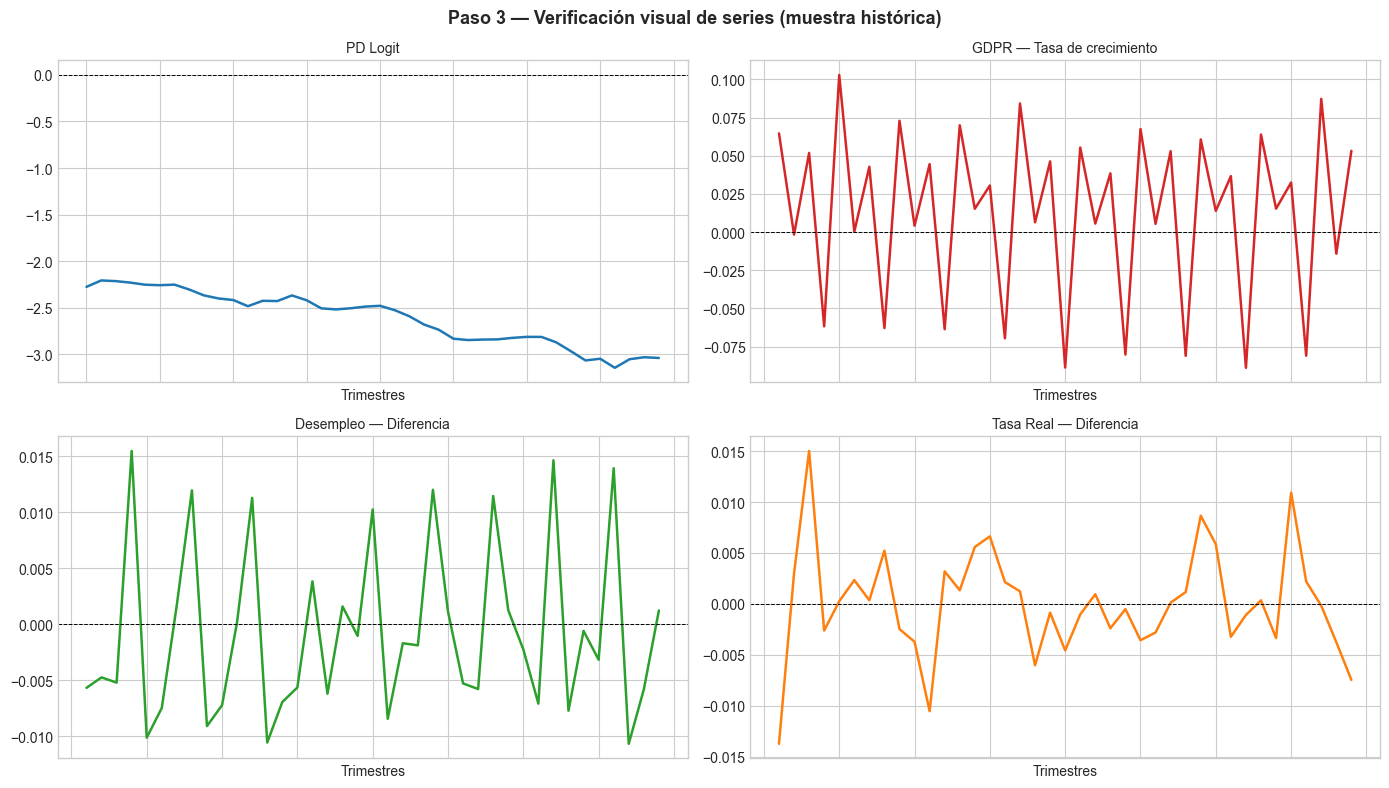


Las series en diferencias y log-diferencias suelen ser estacionarias.
   Las series en nivel (log) pueden presentar tendencia → preferir sus diferencias.


In [7]:
# ── Visualización: PD_logit y GDP_logdifa ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Paso 3 — Verificación visual de series (muestra histórica)', fontsize=13, fontweight='bold')

series_plot = [
    ('PD_logit',             'PD Logit',                  COLORS[0]),
    ('GDPR_logdifa',         'GDPR — Tasa de crecimiento',COLORS[1]),
    ('Unemployment_difa',    'Desempleo — Diferencia',    COLORS[2]),
    ('InterestRatesReal_difa','Tasa Real — Diferencia',   COLORS[3]),
]

for ax, (col, titulo, color) in zip(axes.flatten(), series_plot):
    if col in df_hist.columns:
        ax.plot(range(len(df_hist)), df_hist[col].values, color=color, lw=1.8)
        ax.axhline(0, color='black', lw=0.7, linestyle='--')
        ax.set_title(titulo, fontsize=10)
        ax.set_xlabel('Trimestres')
        ax.tick_params(axis='x', which='both', labelbottom=False)

plt.tight_layout()
plt.savefig('fig_paso3_series.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nLas series en diferencias y log-diferencias suelen ser estacionarias.")
print("   Las series en nivel (log) pueden presentar tendencia → preferir sus diferencias.")

In [8]:
# ── Suavización de series no estacionarias ────────────────────────────────
# Identificar series no estacionarias según ADF
no_estac = df_adf.loc[df_adf['estacionaria'] == '❌ No', 'variable'].tolist()
print(f"Series NO estacionarias que recibirán suavización: {no_estac}")

ALPHA_SES = 0.3   # Parámetro de suavización (0.3 = memoria moderada)

for v in no_estac:
    if v in df.columns:
        col_smooth = f'{v}_smooth'
        df[col_smooth] = smooth_ses(df[v], alpha=ALPHA_SES)
        print(f"  ✅ {v} → {col_smooth} creada")

# Si PD_logit no es estacionaria, suavizarla también para el análisis
if 'PD_logit' in no_estac:
    df['PD_logit_smooth'] = smooth_ses(df['PD_logit'], alpha=ALPHA_SES)
    TARGET = 'PD_logit_smooth'
    print("\n PD_logit no es estacionaria → se usará PD_logit_smooth como variable dependiente")
else:
    TARGET = 'PD_logit'
    print("\n✅ PD_logit es estacionaria → se usará directamente como variable dependiente")

print(f"\n→ Variable dependiente del modelo: '{TARGET}'")

Series NO estacionarias que recibirán suavización: ['PD_logit', 'GDPR_logdifa', 'GDPR_difa', 'GDPR_log', 'Unemployment_difa', 'Unemployment_logdifa', 'Unemployment_log', 'Consumption_difa', 'Consumption_logdifa']
  ✅ PD_logit → PD_logit_smooth creada
  ✅ GDPR_logdifa → GDPR_logdifa_smooth creada
  ✅ GDPR_difa → GDPR_difa_smooth creada
  ✅ GDPR_log → GDPR_log_smooth creada
  ✅ Unemployment_difa → Unemployment_difa_smooth creada
  ✅ Unemployment_logdifa → Unemployment_logdifa_smooth creada
  ✅ Unemployment_log → Unemployment_log_smooth creada
  ✅ Consumption_difa → Consumption_difa_smooth creada
  ✅ Consumption_logdifa → Consumption_logdifa_smooth creada

 PD_logit no es estacionaria → se usará PD_logit_smooth como variable dependiente

→ Variable dependiente del modelo: 'PD_logit_smooth'


## **3. Construcción de rezagos y adelantos**

En macroeconomía, el impacto de un shock económico en la calidad crediticia **no es inmediato**. Un aumento del desempleo hoy puede tardar 2-3 trimestres en reflejarse en mayores defaults.

- **Rezago (lag) k**: $X_{t-k}$ → el valor de la variable $k$ períodos atrás
- **Adelanto (lead) k**: $X_{t+k}$ → el valor de la variable $k$ períodos adelante

**Regla de parsimonia aplicada:** Si se incluye un lag 4 y un lag 2, **necesariamente debe incluirse el lag 3** (no se pueden saltar lags intermedios en la especificación final).

In [9]:
MAX_LAG  = 4   # rezagos máximos
MAX_LEAD = 4   # adelantos máximos

lag_lead_cols = []

for col in transformed_cols:
    for k in range(1, MAX_LAG + 1):
        new_col = f'{col}_L{k}'
        df[new_col] = df[col].shift(k)
        lag_lead_cols.append(new_col)

    for k in range(1, MAX_LEAD + 1):
        new_col = f'{col}_F{k}'
        df[new_col] = df[col].shift(-k)
        lag_lead_cols.append(new_col)

# Agregar también el rezago de la PD_logit (componente autoregresivo)
df['PD_logit_L1'] = df['PD_logit'].shift(1)

print(f"Total de columnas generadas (transformadas + rezagos/adelantos): {len(transformed_cols) + len(lag_lead_cols)}")
print(f"   + 1 componente autoregresivo (PD_logit_L1)")
print(f"\nEjemplo de rezagos de GDPR_logdifa:")
df[['periodo', 'GDPR_logdifa', 'GDPR_logdifa_L1', 'GDPR_logdifa_L2', 'GDPR_logdifa_L3', 'GDPR_logdifa_L4']].dropna().head(8)

Total de columnas generadas (transformadas + rezagos/adelantos): 270
   + 1 componente autoregresivo (PD_logit_L1)

Ejemplo de rezagos de GDPR_logdifa:


,periodo,GDPR_logdifa,GDPR_logdifa_L1,GDPR_logdifa_L2,GDPR_logdifa_L3,GDPR_logdifa_L4
5,2010-2Q,0.102844,-0.061669,0.051825,-0.001632,0.064605
6,2010-3Q,0.000326,0.102844,-0.061669,0.051825,-0.001632
7,2010-4Q,0.042787,0.000326,0.102844,-0.061669,0.051825
8,2011-1Q,-0.062823,0.042787,0.000326,0.102844,-0.061669
9,2011-2Q,0.072859,-0.062823,0.042787,0.000326,0.102844
10,2011-3Q,0.004195,0.072859,-0.062823,0.042787,0.000326
11,2011-4Q,0.044496,0.004195,0.072859,-0.062823,0.042787
12,2012-1Q,-0.063551,0.044496,0.004195,0.072859,-0.062823


In [10]:
df.head()

,periodo,pd,GDPR,Unemployment,GFCF,Consumption,InterestRatesReal,EMBI,FiscalBalance,FX,Sov1Y,Sov2Y,Sov3Y,Sov10Y,PD_logit,GDPR_difa,GDPR_log,GDPR_logdifa,Unemployment_difa,Unemployment_log,Unemployment_logdifa,GFCF_difa,GFCF_log,GFCF_logdifa,Consumption_difa,Consumption_log,Consumption_logdifa,InterestRatesReal_difa,InterestRatesReal_logdifa,EMBI_difa,EMBI_log,EMBI_logdifa,FiscalBalance_difa,FiscalBalance_logdifa,FX_difa,FX_log,FX_logdifa,Sov1Y_difa,Sov1Y_logdifa,Sov2Y_difa,Sov2Y_logdifa,Sov3Y_difa,Sov3Y_logdifa,Sov10Y_difa,Sov10Y_logdifa,PD_logit_smooth,GDPR_logdifa_smooth,GDPR_difa_smooth,GDPR_log_smooth,Unemployment_difa_smooth,Unemployment_logdifa_smooth,Unemployment_log_smooth,Consumption_difa_smooth,Consumption_logdifa_smooth,GDPR_difa_L1,GDPR_difa_L2,GDPR_difa_L3,GDPR_difa_L4,GDPR_difa_F1,GDPR_difa_F2,GDPR_difa_F3,GDPR_difa_F4,GDPR_log_L1,GDPR_log_L2,GDPR_log_L3,GDPR_log_L4,GDPR_log_F1,GDPR_log_F2,GDPR_log_F3,GDPR_log_F4,GDPR_logdifa_L1,GDPR_logdifa_L2,GDPR_logdifa_L3,GDPR_logdifa_L4,GDPR_logdifa_F1,GDPR_logdifa_F2,GDPR_logdifa_F3,GDPR_logdifa_F4,Unemployment_difa_L1,Unemployment_difa_L2,Unemployment_difa_L3,Unemployment_difa_L4,Unemployment_difa_F1,Unemployment_difa_F2,Unemployment_difa_F3,Unemployment_difa_F4,Unemployment_log_L1,Unemployment_log_L2,Unemployment_log_L3,Unemployment_log_L4,Unemployment_log_F1,Unemployment_log_F2,Unemployment_log_F3,Unemployment_log_F4,Unemployment_logdifa_L1,Unemployment_logdifa_L2,Unemployment_logdifa_L3,Unemployment_logdifa_L4,Unemployment_logdifa_F1,Unemployment_logdifa_F2,Unemployment_logdifa_F3,Unemployment_logdifa_F4,GFCF_difa_L1,GFCF_difa_L2,GFCF_difa_L3,GFCF_difa_L4,GFCF_difa_F1,GFCF_difa_F2,GFCF_difa_F3,GFCF_difa_F4,GFCF_log_L1,GFCF_log_L2,GFCF_log_L3,GFCF_log_L4,GFCF_log_F1,GFCF_log_F2,GFCF_log_F3,GFCF_log_F4,GFCF_logdifa_L1,GFCF_logdifa_L2,GFCF_logdifa_L3,GFCF_logdifa_L4,GFCF_logdifa_F1,GFCF_logdifa_F2,GFCF_logdifa_F3,GFCF_logdifa_F4,Consumption_difa_L1,Consumption_difa_L2,Consumption_difa_L3,Consumption_difa_L4,Consumption_difa_F1,Consumption_difa_F2,Consumption_difa_F3,Consumption_difa_F4,Consumption_log_L1,Consumption_log_L2,Consumption_log_L3,Consumption_log_L4,Consumption_log_F1,Consumption_log_F2,Consumption_log_F3,Consumption_log_F4,Consumption_logdifa_L1,Consumption_logdifa_L2,Consumption_logdifa_L3,Consumption_logdifa_L4,Consumption_logdifa_F1,Consumption_logdifa_F2,Consumption_logdifa_F3,Consumption_logdifa_F4,InterestRatesReal_difa_L1,InterestRatesReal_difa_L2,InterestRatesReal_difa_L3,InterestRatesReal_difa_L4,InterestRatesReal_difa_F1,InterestRatesReal_difa_F2,InterestRatesReal_difa_F3,InterestRatesReal_difa_F4,InterestRatesReal_logdifa_L1,InterestRatesReal_logdifa_L2,InterestRatesReal_logdifa_L3,InterestRatesReal_logdifa_L4,InterestRatesReal_logdifa_F1,InterestRatesReal_logdifa_F2,InterestRatesReal_logdifa_F3,InterestRatesReal_logdifa_F4,EMBI_difa_L1,EMBI_difa_L2,EMBI_difa_L3,EMBI_difa_L4,EMBI_difa_F1,EMBI_difa_F2,EMBI_difa_F3,EMBI_difa_F4,EMBI_log_L1,EMBI_log_L2,EMBI_log_L3,EMBI_log_L4,EMBI_log_F1,EMBI_log_F2,EMBI_log_F3,EMBI_log_F4,EMBI_logdifa_L1,EMBI_logdifa_L2,EMBI_logdifa_L3,EMBI_logdifa_L4,EMBI_logdifa_F1,EMBI_logdifa_F2,EMBI_logdifa_F3,EMBI_logdifa_F4,FiscalBalance_difa_L1,FiscalBalance_difa_L2,FiscalBalance_difa_L3,FiscalBalance_difa_L4,FiscalBalance_difa_F1,FiscalBalance_difa_F2,FiscalBalance_difa_F3,FiscalBalance_difa_F4,FiscalBalance_logdifa_L1,FiscalBalance_logdifa_L2,FiscalBalance_logdifa_L3,FiscalBalance_logdifa_L4,FiscalBalance_logdifa_F1,FiscalBalance_logdifa_F2,FiscalBalance_logdifa_F3,FiscalBalance_logdifa_F4,FX_difa_L1,FX_difa_L2,FX_difa_L3,FX_difa_L4,FX_difa_F1,FX_difa_F2,FX_difa_F3,FX_difa_F4,FX_log_L1,FX_log_L2,FX_log_L3,FX_log_L4,FX_log_F1,FX_log_F2,FX_log_F3,FX_log_F4,FX_logdifa_L1,FX_logdifa_L2,FX_logdifa_L3,FX_logdifa_L4,FX_logdifa_F1,FX_logdifa_F2,FX_logdifa_F3,FX_logdifa_F4,Sov1Y_difa_L1,Sov1Y_difa_L2,Sov1Y_difa_L3,Sov1Y_difa_L4,Sov1Y_difa_F1,Sov1Y_difa_F2,Sov1Y_difa_F3,Sov1Y_difa_F4,Sov1Y_logdifa_L1,Sov1Y_logdifa_L2,Sov1Y_logdifa_L3,

##  **5. Selección de variables y estimación de modelos candidatos**

### Estrategia de selección

Dado el principio de **parsimonia** (modelos simples y robustos > modelos complejos y sobreajustados), la estrategia es:

1. **Prioridad de variables**: GDP, Unemployment, Consumption, InterestRate (por economía crediticia)
2. **Máximo 3 variables macro** por modelo + 1 componente autoregresivo (PD_logit_L1)
3. **Regla de lags**: Si se usa lag 4 y lag 2 → lag 3 es obligatorio
4. **Signo esperado**: GDP↑ → PD↓ (negativo); Unemployment↑ → PD↑ (positivo)

### Modelos candidatos propuestos

Definiremos 3 modelos con especificaciones que capturan distintas dimensiones del riesgo crediticio vehicular:

| Modelo | Lógica económica |
|--------|------------------|
| **M1** | Actividad económica (GDPR) + Mercado laboral (Unemployment) + Autoregresivo |
| **M2** | GDPR + Tasa de interés real + Autoregresivo |
| **M3** | GDPR + Consumption + Tipo de cambio (FX) + Autoregresivo |

In [ ]:
df.head()

In [12]:
# ── Preparar muestra de estimación ───────────────────────────────────────
# Usar solo periodo donde tenemos PD observada
df_model = df[df['pd'].notna()].copy().reset_index(drop=True)

# ── Definición de los 3 modelos candidatos ────────────────────────────────
# Cada modelo: lista de regresores (sin constante, se agrega en la estimación)
# Se incluye siempre el componente autoregresivo PD_logit_L1

MODELOS = {
    'M1 — GDP + Desempleo + AR(1)': [
        'PD_logit_L1',          # Componente autoregresivo
        'GDPR_logdifa',         # Tasa crecimiento PIB (contemporánea)
        'GDPR_logdifa_L1',      # Tasa crecimiento PIB rezago 1
        'Unemployment_difa',    # Variación desempleo contemporánea
    ],
    'M2 — GDP + Tasa Interés + AR(1)': [
        'PD_logit_L1',
        'GDPR_difa_F4',      # Tasa crecimiento PIB adelanto 4 periodos
        'InterestRatesReal_difa_F2',# Adelanto 2 tasa real
    ],
    'M3 — GDP + Consumo + FX + AR(1)': [
        'PD_logit_L1',
        'GDPR_logdifa',             # Actividad económica
        'Consumption_logdifa',      # Consumo privado
        'Consumption_logdifa_L1',   # Rezago 1 consumo
        'FX_logdifa',               # Depreciación cambiaria
    ],
}

print("Modelos candidatos definidos:")
for nombre, vars_list in MODELOS.items():
    print(f"\n  {nombre}")
    for v in vars_list:
        print(f"    • {v}")

Modelos candidatos definidos:

  M1 — GDP + Desempleo + AR(1)
    • PD_logit_L1
    • GDPR_logdifa
    • GDPR_logdifa_L1
    • Unemployment_difa

  M2 — GDP + Tasa Interés + AR(1)
    • PD_logit_L1
    • GDPR_difa_F4
    • InterestRatesReal_difa_F2

  M3 — GDP + Consumo + FX + AR(1)
    • PD_logit_L1
    • GDPR_logdifa
    • Consumption_logdifa
    • Consumption_logdifa_L1
    • FX_logdifa


In [13]:
# ── Función de estimación OLS ─────────────────────────────────────────────
def estimar_modelo(df_est, target, regressors, nombre):
    """
    Estima un modelo OLS con statsmodels.
    Retorna: (resultado_sm, df_metricas, df_coefs)
    """
    # Seleccionar columnas relevantes y eliminar NaN
    cols_needed = [target] + regressors
    df_est_clean = df_est[cols_needed].dropna()

    y = df_est_clean[target]
    X = sm.add_constant(df_est_clean[regressors])

    modelo = sm.OLS(y, X).fit(cov_type='HC3')  # HC3 = errores robustos a heterocedasticidad

    # ── Coeficientes ─────────────────────────────────────────────────────
    df_coefs = pd.DataFrame({
        'Variable'   : modelo.params.index,
        'Coeficiente': modelo.params.values,
        'Std Error'  : modelo.bse.values,
        't-stat'     : modelo.tvalues.values,
        'p-value'    : modelo.pvalues.values,
        'Sig'        : ['***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
                        for p in modelo.pvalues.values]
    })

    # ── Peso relativo de variables (|coef| / sum|coef|, excluyendo constante y AR) ─
    macro_regs = [r for r in regressors if r != 'PD_logit_L1']
    coef_macro  = df_coefs[df_coefs['Variable'].isin(macro_regs)].copy()
    total_abs   = coef_macro['Coeficiente'].abs().sum()
    if total_abs > 0:
        df_coefs.loc[df_coefs['Variable'].isin(macro_regs), 'Peso (%)'] = \
            (coef_macro['Coeficiente'].abs() / total_abs * 100).values
    peso_ar = None
    if 'PD_logit_L1' in regressors:
        peso_ar = float(df_coefs.loc[df_coefs['Variable'] == 'PD_logit_L1', 'Coeficiente'].values[0])

    # ── Métricas del modelo ───────────────────────────────────────────────
    y_pred    = modelo.fittedvalues
    mape      = np.mean(np.abs((y.values - y_pred.values) / (y.values + 1e-9))) * 100

    df_metricas = pd.DataFrame([{
        'Modelo'  : nombre,
        'N obs'   : int(modelo.nobs),
        'R²'      : round(modelo.rsquared, 4),
        'R² Adj'  : round(modelo.rsquared_adj, 4),
        'AIC'     : round(modelo.aic, 2),
        'BIC'     : round(modelo.bic, 2),
        'MAPE (%)'   : round(mape, 3),
        'Coef AR(1)' : round(peso_ar, 4) if peso_ar else 'N/A',
    }])

    return modelo, df_metricas, df_coefs

print("Función de estimación definida")

Función de estimación definida


In [14]:
# ── Estimar los 3 modelos ─────────────────────────────────────────────────
resultados = {}   # nombre → (sm_model, df_metricas, df_coefs)

for nombre, regressors in MODELOS.items():
    sm_model, df_met, df_coef = estimar_modelo(df_model, TARGET, regressors, nombre)
    resultados[nombre] = (sm_model, df_met, df_coef)
    print(f"\n{'='*65}")
    print(f"  {nombre}")
    print(f"{'='*65}")
    print(df_coef[['Variable','Coeficiente','p-value','Sig','Peso (%)']].fillna('—').to_string(index=False))
    print(f"\n  R²={df_met['R²'].values[0]}  |  R²Adj={df_met['R² Adj'].values[0]}  "
          f"|  AIC={df_met['AIC'].values[0]}  |  MAPE={df_met['MAPE (%)'].values[0]}%  "
          f"|  Coef AR(1)={df_met['Coef AR(1)'].values[0]}")


  M1 — GDP + Desempleo + AR(1)
         Variable  Coeficiente  p-value Sig   Peso (%)
            const    -0.168143 0.005686 ***          —
      PD_logit_L1     0.926690 0.000000 ***          —
     GDPR_logdifa     0.149870 0.543912       28.86911
  GDPR_logdifa_L1     0.085080 0.566565      16.388861
Unemployment_difa     0.284185 0.847393      54.742029

  R²=0.9861  |  R²Adj=0.9844  |  AIC=-146.93  |  MAPE=0.962%  |  Coef AR(1)=0.9267

  M2 — GDP + Tasa Interés + AR(1)
                 Variable   Coeficiente  p-value Sig   Peso (%)
                    const -1.612829e-01 0.004791 ***          —
              PD_logit_L1  9.283535e-01 0.000000 ***          —
             GDPR_difa_F4  3.745480e-07 0.679765       0.000053
InterestRatesReal_difa_F2  7.042012e-01 0.612551      99.999947

  R²=0.9865  |  R²Adj=0.9853  |  AIC=-153.72  |  MAPE=0.953%  |  Coef AR(1)=0.9284

  M3 — GDP + Consumo + FX + AR(1)
              Variable  Coeficiente  p-value Sig   Peso (%)
                 con

## **6. Tabla comparativa y selección del modelo final**

### Criterios de selección (en orden de importancia):

1. **Sentido económico**: Los signos de los coeficientes deben ser coherentes con la teoría
   - PIB↑ → PD↓ (coef negativo)
   - Desempleo↑ → PD↑ (coef positivo)
   - Consumo↑ → PD↓ (coef negativo)
   - Tasa interés↑ → PD↑ (coef positivo)

2. **Estadísticos**: R² ajustado alto, AIC/BIC bajos, MAPE bajo

3. **Significancia**: p-value < 0.05 en los coeficientes principales

4. **Proyecciones no explosivas**: La PD proyectada debe ser razonable y acotada

In [15]:
# ── Tabla comparativa de métricas ─────────────────────────────────────────
df_comparativa = pd.concat([v[1] for v in resultados.values()], ignore_index=True)

print("\n" + "="*70)
print("TABLA COMPARATIVA DE MODELOS")
print("="*70)
print(df_comparativa.to_string(index=False))
print("="*70)
print("\n💡 Criterios de selección:")
print("   ✔ Mayor R² Ajustado")
print("   ✔ Menor AIC / BIC (parsimonia)")
print("   ✔ Menor MAPE (ajuste en muestra)")
print("   ✔ Signos coherentes con teoría económica")
print("   ✔ Proyecciones futuras acotadas (no explosivas)")


TABLA COMPARATIVA DE MODELOS
                         Modelo  N obs     R²  R² Adj     AIC     BIC  MAPE (%)  Coef AR(1)
   M1 — GDP + Desempleo + AR(1)     38 0.9861  0.9844 -146.93 -138.74     0.962      0.9267
M2 — GDP + Tasa Interés + AR(1)     39 0.9865  0.9853 -153.72 -147.07     0.953      0.9284
M3 — GDP + Consumo + FX + AR(1)     38 0.9879  0.9860 -150.25 -140.43     0.900      0.9313

💡 Criterios de selección:
   ✔ Mayor R² Ajustado
   ✔ Menor AIC / BIC (parsimonia)
   ✔ Menor MAPE (ajuste en muestra)
   ✔ Signos coherentes con teoría económica
   ✔ Proyecciones futuras acotadas (no explosivas)


In [17]:
# ── Verificación de sentido económico ─────────────────────────────────────
# Signos esperados por variable
SIGNO_ESPERADO = {
    'GDPR_logdifa'              : '-',  # PIB crece → PD baja
    'GDPR_logdifa_L1'           : '-',
    'Unemployment_difa'         : '+',  # Desempleo sube → PD sube
    'Consumption_logdifa'       : '-',  # Consumo crece → PD baja
    'Consumption_logdifa_L1'    : '-',
    'InterestRatesReal_difa'    : '+',  # Tasa sube → PD sube
    'InterestRatesReal_difa_L1' : '+',
    'FX_logdifa'                : '+',  # Depreciación → PD sube
    'PD_logit_L1'               : '+',  # Persistencia positiva
}

print("\nVERIFICACIÓN DE SENTIDO ECONÓMICO")
print("="*65)
for nombre, (_, _, df_coef) in resultados.items():
    print(f"\n  {nombre}")
    for _, row in df_coef.iterrows():
        var = row['Variable']
        if var == 'const':
            continue
        coef = row['Coeficiente']
        signo_obs = '+' if coef > 0 else '-'
        esperado  = SIGNO_ESPERADO.get(var, '?')
        ok = '✅' if (esperado == '?' or signo_obs == esperado) else '❌'
        print(f"    {ok} {var:40s}: coef={coef:+.4f}  (esperado: {esperado})")


VERIFICACIÓN DE SENTIDO ECONÓMICO

  M1 — GDP + Desempleo + AR(1)
    ✅ PD_logit_L1                             : coef=+0.9267  (esperado: +)
    ❌ GDPR_logdifa                            : coef=+0.1499  (esperado: -)
    ❌ GDPR_logdifa_L1                         : coef=+0.0851  (esperado: -)
    ✅ Unemployment_difa                       : coef=+0.2842  (esperado: +)

  M2 — GDP + Tasa Interés + AR(1)
    ✅ PD_logit_L1                             : coef=+0.9284  (esperado: +)
    ✅ GDPR_difa_F4                            : coef=+0.0000  (esperado: ?)
    ✅ InterestRatesReal_difa_F2               : coef=+0.7042  (esperado: ?)

  M3 — GDP + Consumo + FX + AR(1)
    ✅ PD_logit_L1                             : coef=+0.9313  (esperado: +)
    ✅ GDPR_logdifa                            : coef=-0.0164  (esperado: -)
    ❌ Consumption_logdifa                     : coef=+0.2817  (esperado: -)
    ❌ Consumption_logdifa_L1                  : coef=+0.1113  (esperado: -)
    ✅ FX_logdifa           

In [18]:
# ── Selección del modelo ganador ──────────────────────────────────────────
# Criterio automático: mejor R² Adj + menor MAPE
# (El analista debe validar también el sentido económico y las proyecciones)

df_comp_sort = df_comparativa.sort_values(['R² Adj', 'MAPE (%)'], ascending=[False, True])
MODELO_GANADOR = df_comp_sort['Modelo'].iloc[0]

print(f"\n Modelo seleccionado (por estadísticos): {MODELO_GANADOR}")
print("\n IMPORTANTE: Validar manualmente:")
print("   1. Que los signos de los coeficientes sean económicamente razonables")
print("   2. Que las proyecciones futuras no sean explosivas")
print("   3. Que los coeficientes clave sean significativos (p < 0.05)")

# Para el resto del notebook usaremos el modelo ganador
sm_final, _, df_coef_final = resultados[MODELO_GANADOR]
regs_final = MODELOS[MODELO_GANADOR]


 Modelo seleccionado (por estadísticos): M3 — GDP + Consumo + FX + AR(1)

 IMPORTANTE: Validar manualmente:
   1. Que los signos de los coeficientes sean económicamente razonables
   2. Que las proyecciones futuras no sean explosivas
   3. Que los coeficientes clave sean significativos (p < 0.05)


In [19]:
MODELO_GANADOR = 'M2 — GDP + Tasa Interés + AR(1)'
regs_final = MODELOS[MODELO_GANADOR]

In [20]:
# ── Preparar dataset completo (histórico + proyección macro) ──────────────
# Necesitamos recalcular las transformaciones y rezagos sobre el df completo
# (ya está hecho en df desde el Paso 2)

# Índice del último dato histórico
idx_ultimo_hist = df[df['pd'].notna()].index[-1]

# ── Proyección recursiva ──────────────────────────────────────────────────
# Para el período de proyección necesitamos construir PD_logit_L1 de forma
# recursiva (usamos la PD proyectada del paso anterior)

coefs = sm_final.params   # coeficientes incluyendo constante

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# DataFrame de proyección: periodos donde PD no está observada
df_proj = df[df['pd'].isna() & df['GDPR'].notna()].copy()

# Inicializar con el último valor histórico de PD_logit
pd_logit_prev = float(df.loc[idx_ultimo_hist, TARGET])

pd_logit_proj = []
pd_proj       = []

for idx, row in df_proj.iterrows():
    # Construir vector X para esta observación
    x_vals = {'const': 1.0}

    for reg in regs_final:
        if reg == 'PD_logit_L1':
            x_vals[reg] = pd_logit_prev   # Valor del paso anterior
        else:
            x_vals[reg] = row.get(reg, np.nan)

    # Si alguna variable macro clave es NaN, usar 0 (asunción neutral)
    x_series = pd.Series(x_vals)
    x_series = x_series.fillna(0)

    # Predicción
    pd_logit_hat = sum(coefs.get(k, 0) * x_series.get(k, 0) for k in coefs.index)
    pd_hat       = sigmoid(pd_logit_hat)

    pd_logit_proj.append(pd_logit_hat)
    pd_proj.append(pd_hat)

    # Actualizar lag autoregresivo
    pd_logit_prev = pd_logit_hat

df_proj['PD_logit_proj'] = pd_logit_proj
df_proj['PD_PIT']        = pd_proj

# Fitted values en muestra histórica
df_model_fit = df_model[['periodo', TARGET, 'pd']].copy()
df_model_fit['PD_fitted_logit'] = sm_final.fittedvalues.reindex(df_model_fit.index)
df_model_fit['PD_fitted']       = sigmoid(df_model_fit['PD_fitted_logit'])

print("✅ Proyección completada")
print(f"   Períodos proyectados: {len(df_proj)}")
print(f"   Rango: {df_proj['periodo'].iloc[0]} – {df_proj['periodo'].iloc[-1]}")
print(f"\nPrimeras proyecciones de PD PIT:")
print(df_proj[['periodo', 'PD_logit_proj', 'PD_PIT']].head(8).to_string(index=False))

✅ Proyección completada
   Períodos proyectados: 24
   Rango: 2019-1Q – 2024-4Q

Primeras proyecciones de PD PIT:
periodo  PD_logit_proj   PD_PIT
2019-1Q      -2.985679 0.048077
2019-2Q      -2.939887 0.050217
2019-3Q      -2.897241 0.052290
2019-4Q      -2.857525 0.054294
2020-1Q      -2.820538 0.056224
2020-2Q      -2.786091 0.058080
2020-3Q      -2.754011 0.059860
2020-4Q      -2.724136 0.061564


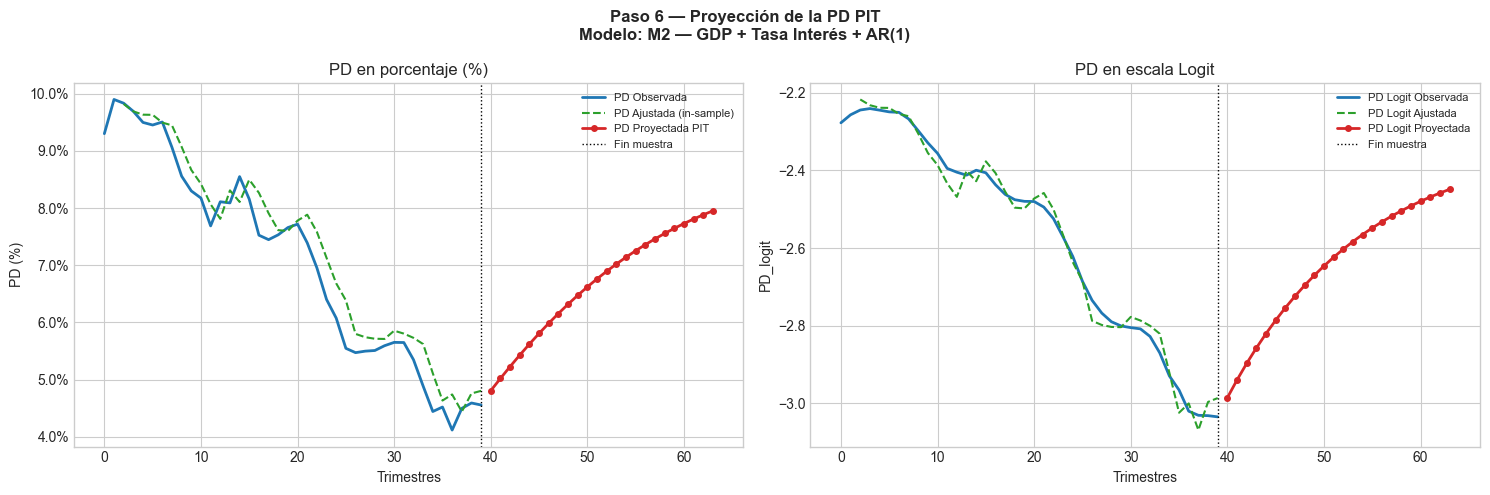


Verificar que la proyección NO sea explosiva (valores extremos o crecimiento sin control).


In [21]:
# ── Gráfico: PD histórica vs fitted vs proyección ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Paso 6 — Proyección de la PD PIT\nModelo: {MODELO_GANADOR}',
             fontsize=12, fontweight='bold')

n_hist = len(df_model_fit)
n_fwd  = len(df_proj)

# ── Panel izquierdo: PD en nivel ─────────────────────────────────────────
ax = axes[0]
ax.plot(range(n_hist), df_model_fit['pd'].values * 100,
        color=COLORS[0], lw=2, label='PD Observada')
ax.plot(range(n_hist), df_model_fit['PD_fitted'].values * 100,
        color=COLORS[2], lw=1.5, linestyle='--', label='PD Ajustada (in-sample)')
ax.plot(range(n_hist, n_hist + n_fwd), df_proj['PD_PIT'].values * 100,
        color=COLORS[1], lw=2, linestyle='-', marker='o', markersize=4,
        label='PD Proyectada PIT')
ax.axvline(n_hist - 1, color='black', lw=1, linestyle=':', label='Fin muestra')
ax.set_title('PD en porcentaje (%)')
ax.set_xlabel('Trimestres')
ax.set_ylabel('PD (%)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# ── Panel derecho: PD_logit ───────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(n_hist), df_model_fit[TARGET].values,
         color=COLORS[0], lw=2, label='PD Logit Observada')
ax2.plot(range(n_hist), df_model_fit['PD_fitted_logit'].values,
         color=COLORS[2], lw=1.5, linestyle='--', label='PD Logit Ajustada')
ax2.plot(range(n_hist, n_hist + n_fwd), df_proj['PD_logit_proj'].values,
         color=COLORS[1], lw=2, linestyle='-', marker='o', markersize=4,
         label='PD Logit Proyectada')
ax2.axvline(n_hist - 1, color='black', lw=1, linestyle=':', label='Fin muestra')
ax2.set_title('PD en escala Logit')
ax2.set_xlabel('Trimestres')
ax2.set_ylabel('PD_logit')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_paso6_proyeccion_pd.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nVerificar que la proyección NO sea explosiva (valores extremos o crecimiento sin control).")

## **7. Cálculo de la PD Forward-Looking bajo IFRS 9**

### Marco conceptual

Bajo IFRS 9, la PD que se incorpora al cálculo de provisiones debe ser **forward-looking**: debe capturar el deterioro (o mejora) esperado en el perfil de riesgo dado el entorno macroeconómico proyectado.

Para ello definimos tres elementos:

| Componente | Definición | Referencia temporal |
|-----------|------------|--------------------|
| **PD Macro** | PD proyectada por el macromodelo usando las variables macroeconómicas de los **3 primeros trimestres fuera de la muestra** | Futuro próximo |
| **PD PIT** | Último valor observado de PD en la serie histórica | Último dato real |
| **PD Forward-Looking (FL)** | Cociente que mide cuánto se aleja el futuro proyectado del presente observado | Ratio de ajuste |

### Fórmula de la PD Forward-Looking

$$PD_{\text{FL}} = \frac{PD_{\text{Macro}}}{PD_{\text{PIT}}}$$

Donde:
- $PD_{\text{Macro}}$ = Promedio de la PD proyectada por el modelo para los 3 primeros trimestres fuera de muestra
- $PD_{\text{PIT}}$ = Último valor de PD observada (2018Q4)
- $PD_{\text{FL}} > 1$ → El modelo anticipa deterioro futuro (la PD subirá)
- $PD_{\text{FL}} < 1$ → El modelo anticipa mejora futura (la PD bajará)

Este ratio es el **escalar forward-looking** que se aplica sobre la PD base (TTC o PIT) para obtener la PD ajustada que entra al cálculo de la ECL.


In [25]:
df.head()

,periodo,pd,GDPR,Unemployment,GFCF,Consumption,InterestRatesReal,EMBI,FiscalBalance,FX,Sov1Y,Sov2Y,Sov3Y,Sov10Y,PD_logit,GDPR_difa,GDPR_log,GDPR_logdifa,Unemployment_difa,Unemployment_log,Unemployment_logdifa,GFCF_difa,GFCF_log,GFCF_logdifa,Consumption_difa,Consumption_log,Consumption_logdifa,InterestRatesReal_difa,InterestRatesReal_logdifa,EMBI_difa,EMBI_log,EMBI_logdifa,FiscalBalance_difa,FiscalBalance_logdifa,FX_difa,FX_log,FX_logdifa,Sov1Y_difa,Sov1Y_logdifa,Sov2Y_difa,Sov2Y_logdifa,Sov3Y_difa,Sov3Y_logdifa,Sov10Y_difa,Sov10Y_logdifa,PD_logit_smooth,GDPR_logdifa_smooth,GDPR_difa_smooth,GDPR_log_smooth,Unemployment_difa_smooth,Unemployment_logdifa_smooth,Unemployment_log_smooth,Consumption_difa_smooth,Consumption_logdifa_smooth,GDPR_difa_L1,GDPR_difa_L2,GDPR_difa_L3,GDPR_difa_L4,GDPR_difa_F1,GDPR_difa_F2,GDPR_difa_F3,GDPR_difa_F4,GDPR_log_L1,GDPR_log_L2,GDPR_log_L3,GDPR_log_L4,GDPR_log_F1,GDPR_log_F2,GDPR_log_F3,GDPR_log_F4,GDPR_logdifa_L1,GDPR_logdifa_L2,GDPR_logdifa_L3,GDPR_logdifa_L4,GDPR_logdifa_F1,GDPR_logdifa_F2,GDPR_logdifa_F3,GDPR_logdifa_F4,Unemployment_difa_L1,Unemployment_difa_L2,Unemployment_difa_L3,Unemployment_difa_L4,Unemployment_difa_F1,Unemployment_difa_F2,Unemployment_difa_F3,Unemployment_difa_F4,Unemployment_log_L1,Unemployment_log_L2,Unemployment_log_L3,Unemployment_log_L4,Unemployment_log_F1,Unemployment_log_F2,Unemployment_log_F3,Unemployment_log_F4,Unemployment_logdifa_L1,Unemployment_logdifa_L2,Unemployment_logdifa_L3,Unemployment_logdifa_L4,Unemployment_logdifa_F1,Unemployment_logdifa_F2,Unemployment_logdifa_F3,Unemployment_logdifa_F4,GFCF_difa_L1,GFCF_difa_L2,GFCF_difa_L3,GFCF_difa_L4,GFCF_difa_F1,GFCF_difa_F2,GFCF_difa_F3,GFCF_difa_F4,GFCF_log_L1,GFCF_log_L2,GFCF_log_L3,GFCF_log_L4,GFCF_log_F1,GFCF_log_F2,GFCF_log_F3,GFCF_log_F4,GFCF_logdifa_L1,GFCF_logdifa_L2,GFCF_logdifa_L3,GFCF_logdifa_L4,GFCF_logdifa_F1,GFCF_logdifa_F2,GFCF_logdifa_F3,GFCF_logdifa_F4,Consumption_difa_L1,Consumption_difa_L2,Consumption_difa_L3,Consumption_difa_L4,Consumption_difa_F1,Consumption_difa_F2,Consumption_difa_F3,Consumption_difa_F4,Consumption_log_L1,Consumption_log_L2,Consumption_log_L3,Consumption_log_L4,Consumption_log_F1,Consumption_log_F2,Consumption_log_F3,Consumption_log_F4,Consumption_logdifa_L1,Consumption_logdifa_L2,Consumption_logdifa_L3,Consumption_logdifa_L4,Consumption_logdifa_F1,Consumption_logdifa_F2,Consumption_logdifa_F3,Consumption_logdifa_F4,InterestRatesReal_difa_L1,InterestRatesReal_difa_L2,InterestRatesReal_difa_L3,InterestRatesReal_difa_L4,InterestRatesReal_difa_F1,InterestRatesReal_difa_F2,InterestRatesReal_difa_F3,InterestRatesReal_difa_F4,InterestRatesReal_logdifa_L1,InterestRatesReal_logdifa_L2,InterestRatesReal_logdifa_L3,InterestRatesReal_logdifa_L4,InterestRatesReal_logdifa_F1,InterestRatesReal_logdifa_F2,InterestRatesReal_logdifa_F3,InterestRatesReal_logdifa_F4,EMBI_difa_L1,EMBI_difa_L2,EMBI_difa_L3,EMBI_difa_L4,EMBI_difa_F1,EMBI_difa_F2,EMBI_difa_F3,EMBI_difa_F4,EMBI_log_L1,EMBI_log_L2,EMBI_log_L3,EMBI_log_L4,EMBI_log_F1,EMBI_log_F2,EMBI_log_F3,EMBI_log_F4,EMBI_logdifa_L1,EMBI_logdifa_L2,EMBI_logdifa_L3,EMBI_logdifa_L4,EMBI_logdifa_F1,EMBI_logdifa_F2,EMBI_logdifa_F3,EMBI_logdifa_F4,FiscalBalance_difa_L1,FiscalBalance_difa_L2,FiscalBalance_difa_L3,FiscalBalance_difa_L4,FiscalBalance_difa_F1,FiscalBalance_difa_F2,FiscalBalance_difa_F3,FiscalBalance_difa_F4,FiscalBalance_logdifa_L1,FiscalBalance_logdifa_L2,FiscalBalance_logdifa_L3,FiscalBalance_logdifa_L4,FiscalBalance_logdifa_F1,FiscalBalance_logdifa_F2,FiscalBalance_logdifa_F3,FiscalBalance_logdifa_F4,FX_difa_L1,FX_difa_L2,FX_difa_L3,FX_difa_L4,FX_difa_F1,FX_difa_F2,FX_difa_F3,FX_difa_F4,FX_log_L1,FX_log_L2,FX_log_L3,FX_log_L4,FX_log_F1,FX_log_F2,FX_log_F3,FX_log_F4,FX_logdifa_L1,FX_logdifa_L2,FX_logdifa_L3,FX_logdifa_L4,FX_logdifa_F1,FX_logdifa_F2,FX_logdifa_F3,FX_logdifa_F4,Sov1Y_difa_L1,Sov1Y_difa_L2,Sov1Y_difa_L3,Sov1Y_difa_L4,Sov1Y_difa_F1,Sov1Y_difa_F2,Sov1Y_difa_F3,Sov1Y_difa_F4,Sov1Y_logdifa_L1,Sov1Y_logdifa_L2,Sov1Y_logdifa_L3,

np.float64(0.04441133281674181)

In [33]:
pd_hist_serie = df[df['pd'].notna()]['pd']
periodo_pit = ['2018-4Q', '2018-3Q', '2018-2Q', '2018-1Q']
PD_PIT = df[df['periodo'].isin(periodo_pit)]['pd'].mean()

print(f"PD PIT (último dato observado)")
print(f"  Período  : {periodo_pit}")
print(f"  PD PIT   : {PD_PIT:.4%}")

PD PIT (último dato observado)
  Período  : ['2018-4Q', '2018-3Q', '2018-2Q', '2018-1Q']
  PD PIT   : 4.4411%


In [23]:
# ── 7.2 PD Macro — Proyección para los 3 primeros trimestres fuera de muestra
# Usamos la proyección recursiva ya calculada en el Paso 6

N_TRIMESTRES_FORWARD = 3
df_macro_3q = df_proj.head(N_TRIMESTRES_FORWARD)[['periodo', 'PD_PIT']].copy()
df_macro_3q = df_macro_3q.rename(columns={'PD_PIT': 'PD_Macro'})

PD_MACRO = df_macro_3q['PD_Macro'].mean()

print("PD Macro — Primeros 3 trimestres proyectados con el modelo seleccionado:")
print(df_macro_3q.to_string(index=False))
print(f"\n→ PD Macro (promedio 3T): {PD_MACRO:.4%}")

PD Macro — Primeros 3 trimestres proyectados con el modelo seleccionado:
periodo  PD_Macro
2019-1Q  0.048077
2019-2Q  0.050217
2019-3Q  0.052290

→ PD Macro (promedio 3T): 5.0195%


In [24]:
# ── 7.3 PD Forward-Looking — Ratio de ajuste macro ───────────────────────
#
# PD_FL = PD_Macro / PD_PIT
#
# Interpreta el escalar:
#   > 1 → el entorno macro proyectado es peor que el último dato → PD sube
#   < 1 → el entorno macro proyectado es mejor que el último dato → PD baja
#   = 1 → sin cambio esperado

PD_FL = PD_MACRO / PD_PIT

print("="*55)
print("  CÁLCULO DE LA PD FORWARD-LOOKING (IFRS 9)")
print("="*55)
print(f"  PD PIT   (2018Q4 observado) : {PD_PIT:.4%}")
print(f"  PD Macro (promedio 3T proy.): {PD_MACRO:.4%}")
print(f"  ─────────────────────────────────────────")
print(f"  PD FL = PD_Macro / PD_PIT  : {PD_FL:.4f}")
print("="*55)

if PD_FL > 1:
    print(f"\n  → Escalar > 1: el modelo anticipa DETERIORO de la PD")
    print(f"     La PD proyectada es {(PD_FL-1)*100:.1f}% mayor al último dato observado.")
elif PD_FL < 1:
    print(f"\n  → Escalar < 1: el modelo anticipa MEJORA de la PD")
    print(f"     La PD proyectada es {(1-PD_FL)*100:.1f}% menor al último dato observado.")
else:
    print(f"\n  → Escalar = 1: sin cambio esperado.")

print(f"\n  Este escalar se aplica sobre la PD base de la cartera para")
print(f"  obtener la PD ajustada que entra al cálculo de la ECL:")
print(f"  ECL = (PD_base × PD_FL) × LGD × EAD")


  CÁLCULO DE LA PD FORWARD-LOOKING (IFRS 9)
  PD PIT   (2018Q4 observado) : 4.5564%
  PD Macro (promedio 3T proy.): 5.0195%
  ─────────────────────────────────────────
  PD FL = PD_Macro / PD_PIT  : 1.1016

  → Escalar > 1: el modelo anticipa DETERIORO de la PD
     La PD proyectada es 10.2% mayor al último dato observado.

  Este escalar se aplica sobre la PD base de la cartera para
  obtener la PD ajustada que entra al cálculo de la ECL:
  ECL = (PD_base × PD_FL) × LGD × EAD


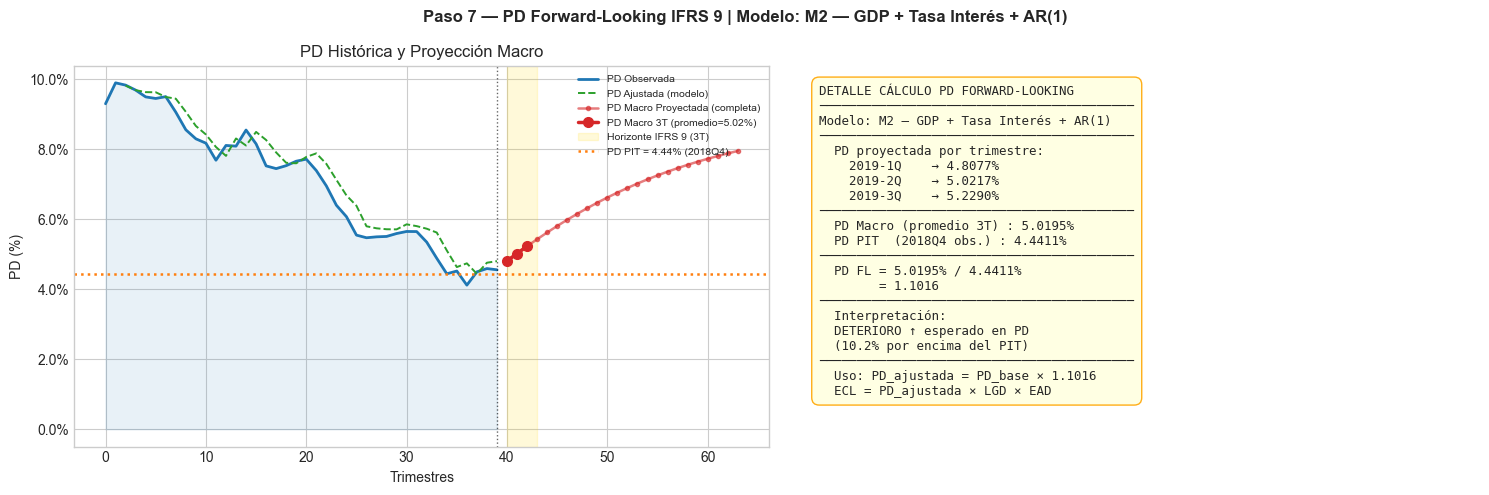

In [ ]:
# ── 7.4 Visualización final ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'Paso 7 — PD Forward-Looking IFRS 9 | Modelo: {MODELO_GANADOR}',
    fontsize=12, fontweight='bold'
)

# ── Panel izquierdo: Serie histórica + proyección + PD PIT ───────────────
ax1 = axes[0]
x_hist = range(n_hist)
x_proj = range(n_hist, n_hist + n_fwd)
x_3q   = range(n_hist, n_hist + N_TRIMESTRES_FORWARD)

ax1.fill_between(x_hist, 0, df_model_fit['pd'].values * 100,
                 alpha=0.10, color=COLORS[0])
ax1.plot(x_hist, df_model_fit['pd'].values * 100,
         color=COLORS[0], lw=2, label='PD Observada')
ax1.plot(x_hist, df_model_fit['PD_fitted'].values * 100,
         color=COLORS[2], lw=1.4, linestyle='--', label='PD Ajustada (modelo)')
ax1.plot(x_proj, df_proj['PD_PIT'].values * 100,
         color=COLORS[1], lw=1.8, linestyle='-',
         marker='o', markersize=3, alpha=0.6, label='PD Macro Proyectada (completa)')

# Destacar los 3 trimestres IFRS 9
ax1.plot(x_3q, df_macro_3q['PD_Macro'].values * 100,
         color=COLORS[1], lw=2.5, marker='o', markersize=7,
         label=f'PD Macro 3T (promedio={PD_MACRO:.2%})')
ax1.axvspan(n_hist, n_hist + N_TRIMESTRES_FORWARD, alpha=0.15,
            color='gold', label='Horizonte IFRS 9 (3T)')

# PD PIT como línea horizontal en el último punto
ax1.axhline(PD_PIT * 100, color=COLORS[3], lw=1.8, linestyle=':',
            label=f'PD PIT = {PD_PIT:.2%} (2018Q4)')
ax1.axvline(n_hist - 1, color='black', lw=1, linestyle=':', alpha=0.6)

ax1.set_ylabel('PD (%)')
ax1.set_xlabel('Trimestres')
ax1.set_title('PD Histórica y Proyección Macro')
ax1.legend(fontsize=7.5, loc='upper right')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# ── Panel derecho: Resumen numérico del escalar FL ───────────────────────
ax2 = axes[1]
ax2.axis('off')

# Tabla de los 3 trimestres
tabla_texto = (
    f"DETALLE CÁLCULO PD FORWARD-LOOKING\n"
    f"{'─'*42}\n"
    f"Modelo: {MODELO_GANADOR}\n"
    f"{'─'*42}\n"
    f"  PD proyectada por trimestre:\n"
)
for _, row in df_macro_3q.iterrows():
    tabla_texto += f"    {row['periodo']:10s} → {row['PD_Macro']:.4%}\n"

tabla_texto += (
    f"{'─'*42}\n"
    f"  PD Macro (promedio 3T) : {PD_MACRO:.4%}\n"
    f"  PD PIT  (2018Q4 obs.) : {PD_PIT:.4%}\n"
    f"{'─'*42}\n"
    f"  PD FL = {PD_MACRO:.4%} / {PD_PIT:.4%}\n"
    f"        = {PD_FL:.4f}\n"
    f"{'─'*42}\n"
    f"  Interpretación:\n"
    f"  {'DETERIORO ↑' if PD_FL>1 else 'MEJORA ↓'} esperado en PD\n"
    f"  ({abs(PD_FL-1)*100:.1f}% {'por encima' if PD_FL>1 else 'por debajo'} del PIT)\n"
    f"{'─'*42}\n"
    f"  Uso: PD_ajustada = PD_base × {PD_FL:.4f}\n"
    f"  ECL = PD_ajustada × LGD × EAD"
)

ax2.text(0.05, 0.95, tabla_texto, transform=ax2.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow',
                   edgecolor='orange', alpha=0.9))

plt.tight_layout()
plt.savefig('fig_paso7_pd_forward_looking.png', dpi=120, bbox_inches='tight')
plt.show()